### Gathering Data

In [1]:
import pandas as pd

In [2]:
run_times = pd.read_excel('data/Run Times.xlsx')

In [3]:
run_times

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,False,$0.00
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,True,$0.00
2,Alexis,8.1209,3 min,“the gym”,2023-05-10 15:00:00,2023-06-01,False,$2.50
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,False,$0.00
4,David,6.8342,2,“gym”,2023-05-10 16:30:00,2023-06-15,False,$2.50


In [4]:
run_times.dtypes

Name                       str
Run Time               float64
Warm Up Time            object
Location                   str
Run Date        datetime64[us]
Race Date       datetime64[us]
Rain                      bool
Fee                        str
dtype: object

In [5]:
run_times.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Name          5 non-null      str           
 1   Run Time      5 non-null      float64       
 2   Warm Up Time  5 non-null      object        
 3   Location      5 non-null      str           
 4   Run Date      5 non-null      datetime64[us]
 5   Race Date     5 non-null      datetime64[us]
 6   Rain          5 non-null      bool          
 7   Fee           5 non-null      str           
dtypes: bool(1), datetime64[us](2), float64(1), object(1), str(3)
memory usage: 417.0+ bytes


In [6]:
run_times.head()

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,False,$0.00
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,True,$0.00
2,Alexis,8.1209,3 min,“the gym”,2023-05-10 15:00:00,2023-06-01,False,$2.50
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,False,$0.00
4,David,6.8342,2,“gym”,2023-05-10 16:30:00,2023-06-15,False,$2.50


In [8]:
run_times.Fee.str.replace('$', '')

0    0.00
1    0.00
2    2.50
3    0.00
4    2.50
Name: Fee, dtype: str

In [13]:
run_times.Fee = pd.to_numeric(run_times.Fee.str.replace('$', ''))

In [14]:
run_times.dtypes

Name                       str
Run Time               float64
Warm Up Time            object
Location                   str
Run Date        datetime64[us]
Race Date       datetime64[us]
Rain                      bool
Fee                    float64
dtype: object

In [16]:
pd.to_numeric(run_times['Warm Up Time'], errors='coerce')

0    3.5
1    3.5
2    NaN
3    2.2
4    2.0
Name: Warm Up Time, dtype: float64

In [18]:
run_times['Warm Up Time']

0      3.5
1      3.5
2    3 min
3      2.2
4        2
Name: Warm Up Time, dtype: object

In [22]:
run_times['Warm Up Time'] = pd.to_numeric(run_times['Warm Up Time'].astype('str').str.replace(' min', ''))

In [23]:
run_times.dtypes

Name                       str
Run Time               float64
Warm Up Time           float64
Location                   str
Run Date        datetime64[us]
Race Date       datetime64[us]
Rain                      bool
Fee                    float64
dtype: object

In [24]:
run_times.head()

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,False,0.0
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,True,0.0
2,Alexis,8.1209,3.0,“the gym”,2023-05-10 15:00:00,2023-06-01,False,2.5
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,False,0.0
4,David,6.8342,2.0,“gym”,2023-05-10 16:30:00,2023-06-15,False,2.5


In [26]:
run_times.Rain.astype('int') # to make boolean seen as 1/0

0    0
1    1
2    0
3    0
4    0
Name: Rain, dtype: int64

### Missing Data

In [27]:
student_grades = pd.read_excel('data/Student Grades.xlsx')

In [28]:
student_grades.tail()

,Student,Class,Year,Grade
81,NaN,NaN,NaN,NaN
82,Bennett,NaN,NaN,NaN
83,NaN,EDA,Junior,84.0
84,Gavin,EDA,Senior,NaN
85,Calvin,NaN,NaN,100.0


In [29]:
np.NaN

NameError: name 'np' is not defined

In [30]:
import numpy as np

In [32]:
np.nan

nan

In [33]:
pd.NA

<NA>

In [34]:
None

In [36]:
student_grades.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Student  84 non-null     str    
 1   Class    83 non-null     str    
 2   Year     80 non-null     str    
 3   Grade    82 non-null     float64
dtypes: float64(1), str(3)
memory usage: 2.8 KB


In [39]:
student_grades.Year.value_counts() # not showing empty values by default

Year
Freshman     35
Sophomore    24
Junior       20
Senior        1
Name: count, dtype: int64

In [40]:
student_grades.Year.value_counts(dropna=False) 

Year
Freshman     35
Sophomore    24
Junior       20
NaN           6
Senior        1
Name: count, dtype: int64

In [41]:
student_grades.isna()

,Student,Class,Year,Grade
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
81,True,True,True,True
82,False,True,True,True
83,True,False,False,False
84,False,False,False,True


In [42]:
student_grades.isna().sum() # count missing values in columns

Student    2
Class      3
Year       6
Grade      4
dtype: int64

In [46]:
student_grades.isna().any(axis=1) # returns true if any missing values in a row

0     False
1     False
2     False
3     False
4     False
      ...  
81     True
82     True
83     True
84     True
85     True
Length: 86, dtype: bool

In [60]:
student_grades[student_grades.isna().any(axis=1)] # show only rows with missing values - if present in any column

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0
62,Landon,Exploratory Data Analysis,Junior,NaN
84,Gavin,EDA,Senior,NaN


In [61]:
student_grades[student_grades.isna().any(axis=1)].dropna() # removes rows with missing values present

,Student,Class,Year,Grade


In [62]:
student_grades[student_grades.isna().any(axis=1)].dropna(subset=['Student', 'Class']) # remove rows with missing values in specific columns

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0
62,Landon,Exploratory Data Analysis,Junior,NaN
84,Gavin,EDA,Senior,NaN


In [63]:
student_grades.dropna(subset=['Student', 'Class'], inplace=True) # inplace makes changes permanent

In [64]:
student_grades.shape

(82, 4)

In [66]:
student_grades[student_grades.Grade.isna()] # [] show only the ones that are true

,Student,Class,Year,Grade
62,Landon,Exploratory Data Analysis,Junior,NaN
84,Gavin,EDA,Senior,NaN


In [68]:
student_grades.Grade.mean() # avg grade

np.float64(85.55)

In [76]:
student_grades.Grade = student_grades.Grade.fillna(student_grades.Grade.mean()) # better imputing missing values depending on a class (it involves conditionals)

In [81]:
student_grades.Grade

0     86.00
1     86.00
2     86.00
3     87.00
4     90.00
      ...  
77    85.00
78    93.00
79    91.00
80    87.00
84    85.55
Name: Grade, Length: 82, dtype: float64

In [83]:
student_grades.info()

<class 'pandas.DataFrame'>
Index: 82 entries, 0 to 84
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Student  82 non-null     str    
 1   Class    82 non-null     str    
 2   Year     79 non-null     str    
 3   Grade    82 non-null     float64
dtypes: float64(1), str(3)
memory usage: 3.2 KB


In [85]:
student_grades.dtypes

Student        str
Class          str
Year           str
Grade      float64
dtype: object

In [86]:
student_grades.describe(include='all')

,Student,Class,Year,Grade
count,82,82,79,82.000000
unique,79,6,4,NaN
top,Isaac,Intro to Python,Freshman,NaN
freq,3,25,35,NaN
mean,NaN,NaN,NaN,85.550000
std,NaN,NaN,NaN,15.443965
min,NaN,NaN,NaN,45.000000
25%,NaN,NaN,NaN,81.000000
50%,NaN,NaN,NaN,85.275000
75%,NaN,NaN,NaN,89.750000


In [89]:
student_grades[student_grades.isna().any(axis=1)]

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0


In [90]:
student_grades[student_grades.Class == 'Freshman Seminar']

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
5,Mason,Freshman Seminar,Freshman,90.0
6,Isabella,Freshman Seminar,Freshman,90.0
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0


In [95]:
student_grades.loc[7, 'Year'] = 'Freshman' # update specific value

In [99]:
student_grades[student_grades.Class == 'Freshman Seminar']

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
5,Mason,Freshman Seminar,Freshman,90.0
6,Isabella,Freshman Seminar,Freshman,90.0
7,Jacob,Freshman Seminar,Freshman,88.0
8,William,Freshman Seminar,Freshman,89.0
9,Ethan,Freshman Seminar,Freshman,86.0


In [98]:
student_grades.Year = np.where(student_grades.Year.isna(), 'Freshman', student_grades.Year) # updating multiple missing vlues
student_grades

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.00
1,Olivia,Freshman Seminar,Freshman,86.00
2,Noah,Freshman Seminar,Freshman,86.00
3,Sophia,Freshman Seminar,Freshman,87.00
4,Liam,Freshman Seminar,Freshman,90.00
...,...,...,...,...
77,Aaron,EDA,Junior,85.00
78,Charles,EDA,Junior,93.00
79,Connor,EDA,Junior,91.00
80,Riley,EDA,Junior,87.00


### Inconsistent Text & Typos

In [101]:
student_grades.head()

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0


In [102]:
student_grades.Class.value_counts()

Class
Intro to Python              25
Intro to SQL                 20
Freshman Seminar             12
Exploratory Data Analysis    12
EDA                          12
Python                        1
Name: count, dtype: int64

In [104]:
student_grades[student_grades.Class.isin(['Exploratory Data Analysis', 'EDA'])]

,Student,Class,Year,Grade
58,Evelyn,Exploratory Data Analysis,Sophomore,89.00
59,Jack,Exploratory Data Analysis,Sophomore,84.00
60,Ella,Exploratory Data Analysis,Sophomore,200.00
61,Chloe,Exploratory Data Analysis,Sophomore,87.00
62,Landon,Exploratory Data Analysis,Junior,85.55
63,Christian,Exploratory Data Analysis,Junior,77.00
64,Jordan,Exploratory Data Analysis,Junior,83.00
65,Jonathan,Exploratory Data Analysis,Junior,82.00
66,Levi,Exploratory Data Analysis,Junior,91.00
67,Victoria,Exploratory Data Analysis,Junior,90.00


In [105]:
student_grades[student_grades.Class.isin(['Intro to Python', 'Python'])]

,Student,Class,Year,Grade
12,Alexander,Intro to Python,Freshman,85.0
13,Logan,Intro to Python,Freshman,85.0
14,James,Intro to Python,Freshman,82.0
15,Daniel,Intro to Python,Freshman,85.0
16,Elijah,Intro to Python,Freshman,85.0
17,Benjamin,Intro to Python,Freshman,81.0
18,Mia,Intro to Python,Freshman,80.0
19,Mia,Python,Freshman,80.0
20,Jayden,Intro to Python,Freshman,82.0
21,Aiden,Intro to Python,Freshman,86.0


In [106]:
student_grades.Year.value_counts()

Year
Freshman     38
Sophomore    24
Junior       19
Senior        1
Name: count, dtype: int64

In [107]:
student_grades.Grade.describe()

count     82.000000
mean      85.550000
std       15.443965
min       45.000000
25%       81.000000
50%       85.275000
75%       89.750000
max      200.000000
Name: Grade, dtype: float64

In [108]:
student_grades[student_grades.Grade > 100]

,Student,Class,Year,Grade
60,Ella,Exploratory Data Analysis,Sophomore,200.0


In [109]:
student_grades.Class.value_counts()

Class
Intro to Python              25
Intro to SQL                 20
Freshman Seminar             12
Exploratory Data Analysis    12
EDA                          12
Python                        1
Name: count, dtype: int64

In [110]:
student_grades.Class = np.where(student_grades.Class == 'Python', 'Intro to Python', student_grades.Class) # change Python to Intro to Python

In [111]:
student_grades.Class.value_counts()

Class
Intro to Python              26
Intro to SQL                 20
Freshman Seminar             12
Exploratory Data Analysis    12
EDA                          12
Name: count, dtype: int64

In [112]:
student_grades.Class = np.where(student_grades.Class == 'EDA', 'Exploratory Data Analysis', student_grades.Class)

In [113]:
student_grades.Class.value_counts()

Class
Intro to Python              26
Exploratory Data Analysis    24
Intro to SQL                 20
Freshman Seminar             12
Name: count, dtype: int64

In [117]:
student_grades.Grade = np.where(student_grades.Grade > 100, 100, student_grades.Grade) # change outlier grade of 200 (or if there were > 100)
# you can put calculations in if_true/false in np.where as well!!!

In [115]:
student_grades[student_grades.Grade > 100]

,Student,Class,Year,Grade


In [116]:
student_grades.Grade.describe()

count     82.000000
mean      84.330488
std        8.824663
min       45.000000
25%       81.000000
50%       85.275000
75%       89.750000
max      100.000000
Name: Grade, dtype: float64

#### Mapping Values

In [118]:
student_grades_2 = pd.read_excel('data/Student Grades.xlsx')

In [119]:
student_grades_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Student  84 non-null     str    
 1   Class    83 non-null     str    
 2   Year     80 non-null     str    
 3   Grade    82 non-null     float64
dtypes: float64(1), str(3)
memory usage: 2.8 KB


In [120]:
student_grades_2.Class.value_counts()

Class
Intro to Python              25
Intro to SQL                 20
EDA                          13
Freshman Seminar             12
Exploratory Data Analysis    12
Python                        1
Name: count, dtype: int64

In [122]:
# dictionary: {key: value}
class_mappings = {
    'Intro to Python': 'Intro to Python',
    'Intro to SQL': 'Intro to SQL',
    'EDA': 'Exploratory Data Analysis',
    'Freshman Seminar': 'Freshman Seminar',
    'Exploratory Data Analysis': 'Exploratory Data Analysis',
    'Python': 'Intro to Python',
}

In [126]:
student_grades_2.Class.map(class_mappings).value_counts(dropna=False)

Class
Intro to Python              26
Exploratory Data Analysis    25
Intro to SQL                 20
Freshman Seminar             12
NaN                           3
Name: count, dtype: int64

In [127]:
student_grades_2.Class = student_grades_2.Class.map(class_mappings)

In [128]:
student_grades_2.Class.value_counts()

Class
Intro to Python              26
Exploratory Data Analysis    25
Intro to SQL                 20
Freshman Seminar             12
Name: count, dtype: int64

#### Cleaning Text

In [139]:
run_times

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,school,2023-04-15 12:00:00,2023-06-01,False,0.0
1,Alexis,10.3842,3.5,school,2023-04-22 12:30:00,2023-06-01,True,0.0
2,Alexis,8.1209,3.0,gym,2023-05-10 15:00:00,2023-06-01,False,2.5
3,David,7.2123,2.2,school,2023-05-01 15:15:00,2023-06-15,False,0.0
4,David,6.8342,2.0,gym,2023-05-10 16:30:00,2023-06-15,False,2.5


In [130]:
run_times.Location.value_counts()

Location
“school”     2
School       1
“the gym”    1
“gym”        1
Name: count, dtype: int64

In [131]:
run_times.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Name          5 non-null      str           
 1   Run Time      5 non-null      float64       
 2   Warm Up Time  5 non-null      float64       
 3   Location      5 non-null      str           
 4   Run Date      5 non-null      datetime64[us]
 5   Race Date     5 non-null      datetime64[us]
 6   Rain          5 non-null      bool          
 7   Fee           5 non-null      float64       
dtypes: bool(1), datetime64[us](2), float64(3), str(2)
memory usage: 417.0 bytes


In [138]:
run_times.Location = run_times.Location.str.lower().str.replace('the ', '').str.strip('“”')

#### Duplicate Data

In [140]:
student_grades.head()

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0


In [142]:
student_grades.duplicated().sum()

np.int64(3)

In [144]:
student_grades[student_grades.duplicated()] # this shows only duplicates

,Student,Class,Year,Grade
19,Mia,Intro to Python,Freshman,80.0
43,Isaac,Intro to SQL,Sophomore,96.0
44,Isaac,Intro to SQL,Sophomore,96.0


In [145]:
student_grades[student_grades.duplicated(keep=False)] # show duplicates and originals

,Student,Class,Year,Grade
18,Mia,Intro to Python,Freshman,80.0
19,Mia,Intro to Python,Freshman,80.0
42,Isaac,Intro to SQL,Sophomore,96.0
43,Isaac,Intro to SQL,Sophomore,96.0
44,Isaac,Intro to SQL,Sophomore,96.0


In [149]:
student_grades.drop_duplicates(inplace=True) # delete duplicates and change dataframe

In [159]:
# another way to delete duplicates => assign dataframe to df without duplicates
student_grades = student_grades[~student_grades.duplicated()] # symbol ~ shows everything EXCEPT the condition == show all without duplicates

In [160]:
student_grades[student_grades.duplicated(keep=False)]

,Student,Class,Year,Grade


In [161]:
student_grades.iloc[40:45, :] # showing exact rows and all columns

,Student,Class,Year,Grade
40,Charlotte,Intro to SQL,Sophomore,92.0
41,Isaac,Intro to SQL,Sophomore,96.0
42,Harper,Intro to SQL,Sophomore,93.0
43,Ryan,Intro to SQL,Sophomore,76.0
44,Sofia,Intro to SQL,Sophomore,79.0


In [162]:
student_grades.reset_index(drop=True, inplace=True) # reset indexing

In [163]:
student_grades.iloc[40:45, :]

,Student,Class,Year,Grade
40,Charlotte,Intro to SQL,Sophomore,92.0
41,Isaac,Intro to SQL,Sophomore,96.0
42,Harper,Intro to SQL,Sophomore,93.0
43,Ryan,Intro to SQL,Sophomore,76.0
44,Sofia,Intro to SQL,Sophomore,79.0


#### Outliers

##### Histograms

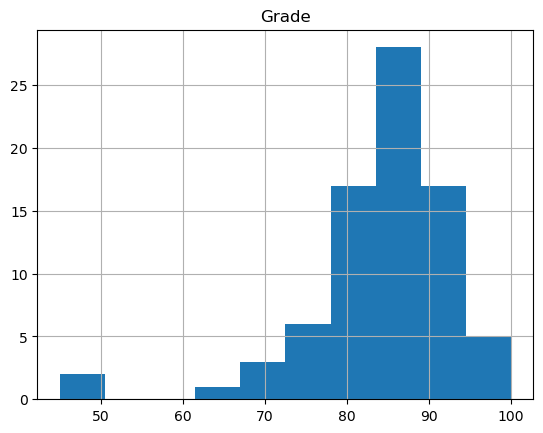

In [171]:
student_grades.hist();

In [172]:
student_grades.Grade.max() - student_grades.Grade.min()

np.float64(55.0)

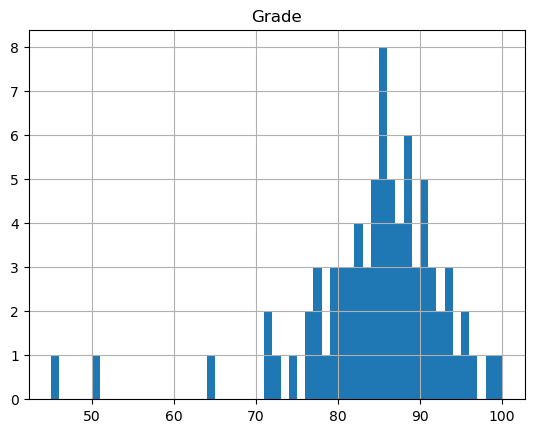

In [173]:
student_grades.hist(bins=55);  # you can always change the number of bins

In [174]:
import seaborn as sns

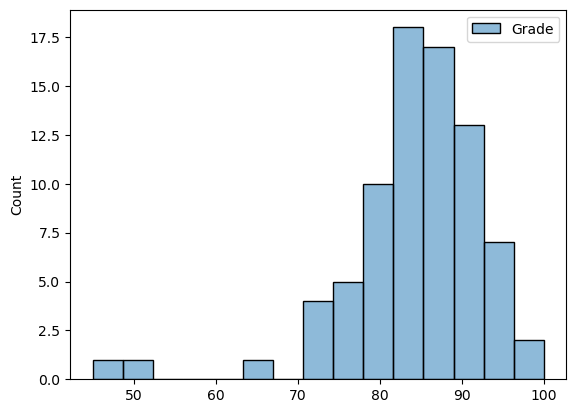

In [177]:
sns.histplot(student_grades); # semicolon 7 removes output before the graph

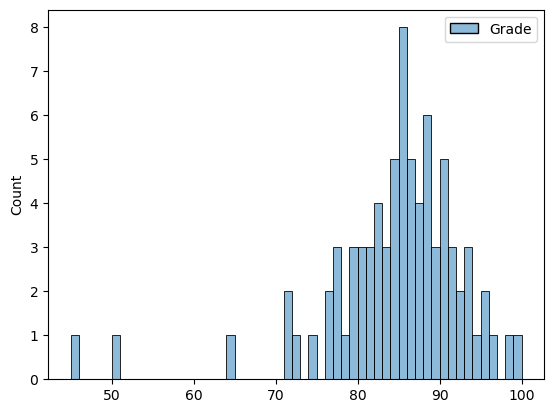

In [178]:
sns.histplot(student_grades, binwidth=1);

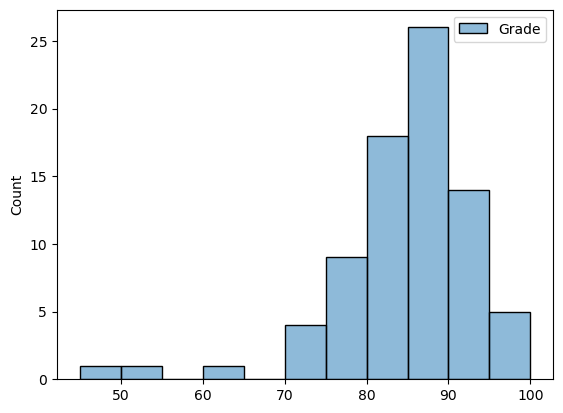

In [179]:
sns.histplot(student_grades, binwidth=5);

##### Box Plots

<Axes: xlabel='Grade'>

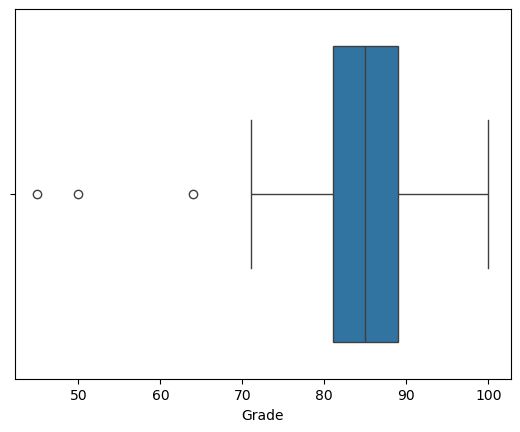

In [181]:
sns.boxplot(x=student_grades.Grade)

In [182]:
q25, q50, q75 = np.percentile(student_grades.Grade, [25, 50, 75])

In [183]:
q25

np.float64(81.0)

In [191]:
iqr = q75 - q25 # interquartile range - it is the middle 50% of the data
iqr

np.float64(8.0)

In [189]:
min_grade = q25 - 1.5*iqr
min_grade

np.float64(69.0)

In [196]:
max_grade = q75 + 1.5*iqr
max_grade

np.float64(101.0)

In [197]:
min_grade, q25, q50, q75, max_grade

(np.float64(69.0),
 np.float64(81.0),
 np.float64(85.0),
 np.float64(89.0),
 np.float64(101.0))

In [198]:
# any value farther away from 1.5*IQR fron each side of the box is considered an outlier
student_grades[student_grades.Grade < 69]

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,50.0
53,Wyatt,Intro to SQL,Sophomore,45.0
66,Jaxon,Exploratory Data Analysis,Junior,64.0


In [199]:
student_grades[student_grades.Grade > 101]

,Student,Class,Year,Grade


##### Standard Deviation

In [201]:
mean = np.mean(student_grades.Grade)

In [202]:
sd = np.std(student_grades.Grade)

In [203]:
mean, sd

(np.float64(84.08987341772152), np.float64(8.723725033779411))

In [204]:
# values at least 3sd away from the mean are considered outliers (can be changed to 2 or 4+)
[grade for grade in student_grades.Grade if (grade < mean - 3*sd) or (grade > mean + 3*sd)]

[50.0, 45.0]

In [205]:
[grade for grade in student_grades.Grade if (grade < mean - 2*sd) or (grade > mean + 2*sd)]

[50.0, 45.0, 64.0]

In [206]:
[grade for grade in student_grades.Grade if (grade < mean - 4*sd) or (grade > mean + 4*sd)]

[45.0]

In [207]:
student_grades.Grade.sort_values()

53     45.0
36     50.0
66     64.0
35     71.0
39     71.0
      ...  
67     95.0
32     95.0
41     96.0
49     98.0
57    100.0
Name: Grade, Length: 79, dtype: float64

In [208]:
student_grades.shape

(79, 4)

In [210]:
student_grades[student_grades.Grade < 60]

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,50.0
53,Wyatt,Intro to SQL,Sophomore,45.0


In [225]:
student_grades.drop([36, 53]) # delete outliers

KeyError: '[36, 53] not found in axis'

In [226]:
student_grades = student_grades[student_grades.Grade >= 60]

In [227]:
student_grades.shape

(77, 4)

In [228]:
min_grade = student_grades[student_grades.Grade >= 60].min()
min_grade

Student                        Aaron
Class      Exploratory Data Analysis
Year                        Freshman
Grade                           64.0
dtype: object

In [229]:
np.where(student_grades.Grade < 60, min_grade, student_grades.Grade) # update outliers with min

ValueError: operands could not be broadcast together with shapes (77,) (4,) (77,) 

In [230]:
student_grades[student_grades.Grade < 60]

,Student,Class,Year,Grade


In [232]:
student_grades.loc[[37, 54]]

,Student,Class,Year,Grade
37,Luke,Intro to SQL,Sophomore,76.0
54,Amelia,Intro to SQL,Sophomore,90.0


In [234]:
student_grades[student_grades.Student == 'Luke']

,Student,Class,Year,Grade
37,Luke,Intro to SQL,Sophomore,76.0


In [235]:
student_grades.loc[37, 'Grade'] = 74

In [236]:
student_grades[student_grades.Student == 'Luke'] # change specific outlier if we know there should be smth different

,Student,Class,Year,Grade
37,Luke,Intro to SQL,Sophomore,74.0


#### Review Cleaned Data

In [237]:
# missing values
student_grades[student_grades.isna().any(axis=1)]

,Student,Class,Year,Grade


In [238]:
# inconsistent text and typos
student_grades.Class.value_counts()

Class
Intro to Python              24
Exploratory Data Analysis    24
Intro to SQL                 17
Freshman Seminar             12
Name: count, dtype: int64

In [240]:
# duplicate data
student_grades[student_grades.duplicated()]

,Student,Class,Year,Grade


<Axes: ylabel='Count'>

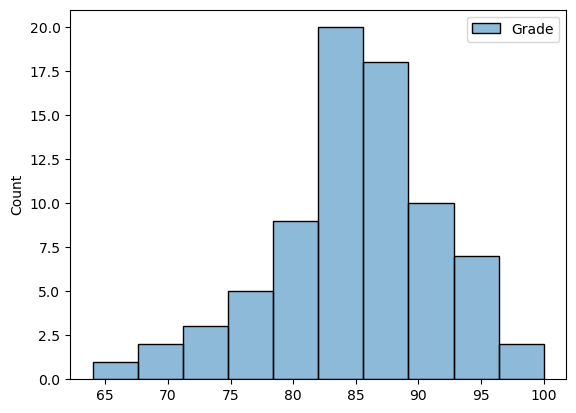

In [242]:
# outliers
sns.histplot(student_grades)

#### Creating New columns

In [2]:
import pandas as pd

In [4]:
groceries = pd.read_excel('data/Groceries.xlsx')
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15


In [5]:
groceries.describe()

,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment
count,25.000000,25.000000,25,25
mean,4.266400,194.280000,2023-06-10 04:18:40.800000,2023-06-19 01:55:12
min,0.400000,5.000000,2023-05-28 22:02:00,2023-06-15 00:00:00
25%,1.780000,78.000000,2023-06-10 12:24:00,2023-06-15 00:00:00
50%,3.500000,178.000000,2023-06-12 17:47:00,2023-06-17 00:00:00
75%,5.990000,284.000000,2023-06-13 07:00:00,2023-06-24 00:00:00
max,10.990000,500.000000,2023-06-13 08:54:00,2023-06-28 00:00:00
std,3.104263,139.015743,NaN,NaN


In [6]:
groceries.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product_ID               25 non-null     str           
 1   Category                 25 non-null     str           
 2   Item                     25 non-null     str           
 3   Price_Dollars            25 non-null     float64       
 4   Inventory                25 non-null     int64         
 5   Last_Updated             25 non-null     datetime64[us]
 6   Next_Scheduled_Shipment  25 non-null     datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), str(3)
memory usage: 1.5 KB


In [11]:
groceries['New_Column'] = round(groceries.Price_Dollars * 1.05, 2) # create new column

In [12]:
groceries.New_Column

0      1.58
1      0.42
2      4.20
3      1.04
4      4.19
5      6.29
6      1.87
7      2.10
8      2.09
9      1.04
10     9.44
11    11.01
12     8.39
13     3.68
14     3.45
15     4.71
16     1.05
17     1.58
18     2.62
19     5.66
20     3.14
21     7.34
22     5.21
23    11.54
24     8.36
Name: New_Column, dtype: float64

In [14]:
groceries['Total_Inventory'] = groceries.Inventory.sum()

In [20]:
groceries['Percent_Inventory'] = round(groceries['Inventory'] / groceries['Total_Inventory'] * 100, 2)  # create new column based on calculation

In [25]:
groceries.head(20)

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Column,Total_Inventory,Percent_Inventory,Low_Inventory
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,
5,P100015,Produce: Fruit,Watermelon,5.99,99,2023-06-12 19:15:00,2023-06-15,6.29,4857,2.04,
6,P100016,Produce: Vegetable,Cabbage,1.78,78,2023-06-12 19:25:00,2023-06-15,1.87,4857,1.61,
7,P100017,Produce: Vegetable,Carrots,2.00,200,2023-06-12 18:05:00,2023-06-15,2.10,4857,4.12,
8,P100018,Produce: Vegetable,Celery,1.99,50,2023-06-12 16:42:00,2023-06-15,2.09,4857,1.03,
9,P100019,Produce: Vegetable,Cucumber,0.99,230,2023-06-12 17:47:00,2023-06-15,1.04,4857,4.74,


In [22]:
import numpy as np

In [23]:
groceries['Low_Inventory'] = np.where(groceries.Inventory < 50, 'Low Inventory', '') # create new column based on condition

##### Creating DateTime Columns

In [27]:
groceries['Last_Updated_Time'] = groceries.Last_Updated.dt.time

In [48]:
groceries.head(20)

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Column,Total_Inventory,Percent_Inventory,Low_Inventory,Last_Updated_Time,Shipment_Day_DOW,Nex_Shipment_Date,Nex_Shipment_Date_Condition
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16,2023-06-16
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16,2023-06-16
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16,2023-06-16
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16,2023-06-16
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16,2023-06-16
5,P100015,Produce: Fruit,Watermelon,5.99,99,2023-06-12 19:15:00,2023-06-15,6.29,4857,2.04,,19:15:00,Thursday,2023-06-16,2023-06-16
6,P100016,Produce: Vegetable,Cabbage,1.78,78,2023-06-12 19:25:00,2023-06-15,1.87,4857,1.61,,19:25:00,Thursday,2023-06-15,2023-06-15
7,P100017,Produce: Vegetable,Carrots,2.00,200,2023-06-12 18:05:00,2023-06-15,2.10,4857,4.12,,18:05:00,Thursday,2023-06-15,2023-06-15
8,P100018,Produce: Vegetable,Celery,1.99,50,2023-06-12 16:42:00,2023-06-15,2.09,4857,1.03,,16:42:00,Thursday,2023-06-15,2023-06-15
9,P100019,Produce: Vegetable,Cucumber,0.99,230,2023-06-12 17:47:00,2023-06-15,1.04,4857,4.74,,17:47:00,Thursday,2023-06-15,2023-06-15


In [30]:
groceries['Shipment_Day_DOW'] = groceries.Next_Scheduled_Shipment.dt.dayofweek

In [32]:
dow_mapping = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

In [35]:
groceries['Shipment_Day_DOW'] = groceries['Shipment_Day_DOW'].map(dow_mapping) # update weekdays with their names - not numbers

In [41]:
groceries['Nex_Shipment_Date'] = groceries.Next_Scheduled_Shipment + pd.to_timedelta(1, 'D') # add days (we cannot just add values to the date, we need to use to_timedelta

In [46]:
# add a condition => update shipmnt date only for fruit category
groceries['Nex_Shipment_Date'] = np.where(
    groceries.Category == 'Produce: Fruit',
    groceries.Next_Scheduled_Shipment + pd.to_timedelta(1, 'D'),
    groceries.Next_Scheduled_Shipment
)

##### Creating Text Columns

In [69]:
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Column,Total_Inventory,Percent_Inventory,Low_Inventory,Last_Updated_Time,Shipment_Day_DOW,Nex_Shipment_Date,Nex_Shipment_Date_Condition,Product_ID_Num,Subcategory
0,P100010,Produce,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16,2023-06-16,100010,Fruit
1,P100011,Produce,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16,2023-06-16,100011,Fruit
2,P100012,Produce,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16,2023-06-16,100012,Fruit
3,P100013,Produce,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16,2023-06-16,100013,Fruit
4,P100014,Produce,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16,2023-06-16,100014,Fruit


In [51]:
groceries['Product_ID_Num'] = groceries.Product_ID.str[1:] # see everything from 2nd carachter till the end

In [56]:
groceries.dtypes

Product_ID                                str
Category                                  str
Item                                      str
Price_Dollars                         float64
Inventory                               int64
Last_Updated                   datetime64[us]
Next_Scheduled_Shipment        datetime64[us]
New_Column                            float64
Total_Inventory                         int64
Percent_Inventory                     float64
Low_Inventory                             str
Last_Updated_Time                      object
Shipment_Day_DOW                          str
Nex_Shipment_Date              datetime64[us]
Nex_Shipment_Date_Condition    datetime64[us]
Product_ID_Num                          int64
dtype: object

In [57]:
groceries.Product_ID_Num = groceries.Product_ID_Num.astype('int') # change type to integer

In [58]:
groceries.Category.value_counts()

Category
Produce: Fruit           6
Produce: Vegetable       4
Produce: Dairy           4
Pantry: Snacks           4
Produce: Meat            3
Frozen: Frozen Snacks    2
Frozen: Frozen Fruit     2
Name: count, dtype: int64

In [64]:
groceries.Category.str.split(':').to_list() # create a list of lists with split values

[['Produce', ' Fruit'],
 ['Produce', ' Fruit'],
 ['Produce', ' Fruit'],
 ['Produce', ' Fruit'],
 ['Produce', ' Fruit'],
 ['Produce', ' Fruit'],
 ['Produce', ' Vegetable'],
 ['Produce', ' Vegetable'],
 ['Produce', ' Vegetable'],
 ['Produce', ' Vegetable'],
 ['Produce', ' Meat'],
 ['Produce', ' Meat'],
 ['Produce', ' Meat'],
 ['Produce', ' Dairy'],
 ['Produce', ' Dairy'],
 ['Produce', ' Dairy'],
 ['Produce', ' Dairy'],
 ['Pantry', ' Snacks'],
 ['Pantry', ' Snacks'],
 ['Pantry', ' Snacks'],
 ['Pantry', ' Snacks'],
 ['Frozen', ' Frozen Snacks'],
 ['Frozen', ' Frozen Snacks'],
 ['Frozen', ' Frozen Fruit'],
 ['Frozen', ' Frozen Fruit']]

In [68]:
groceries[['Category', 'Subcategory']] = pd.DataFrame(groceries.Category.str.split(':').to_list()) # turn that list of lists into 2 columns

In [78]:
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Column,Total_Inventory,Percent_Inventory,Low_Inventory,Last_Updated_Time,Shipment_Day_DOW,Nex_Shipment_Date,Nex_Shipment_Date_Condition,Product_ID_Num,Subcategory,Organic
0,P100010,Produce,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16,2023-06-16,100010,Fruit,False
1,P100011,Produce,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16,2023-06-16,100011,Fruit,False
2,P100012,Produce,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16,2023-06-16,100012,Fruit,False
3,P100013,Produce,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16,2023-06-16,100013,Fruit,False
4,P100014,Produce,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16,2023-06-16,100014,Fruit,True


In [74]:
groceries.Item.str.contains('organic|Organic', regex=True) # it's case sensitive

0     False
1     False
2     False
3     False
4      True
5     False
6     False
7     False
8     False
9     False
10    False
11     True
12    False
13    False
14    False
15    False
16    False
17     True
18    False
19    False
20    False
21    False
22    False
23    False
24    False
Name: Item, dtype: bool

In [77]:
groceries['Organic'] = groceries.Item.str.lower().str.contains('organic') # another option

##### Reorganize columns

In [80]:
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Column,Total_Inventory,Percent_Inventory,Low_Inventory,Last_Updated_Time,Shipment_Day_DOW,Nex_Shipment_Date,Nex_Shipment_Date_Condition,Product_ID_Num,Subcategory,Organic
0,P100010,Produce,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16,2023-06-16,100010,Fruit,False
1,P100011,Produce,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16,2023-06-16,100011,Fruit,False
2,P100012,Produce,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16,2023-06-16,100012,Fruit,False
3,P100013,Produce,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16,2023-06-16,100013,Fruit,False
4,P100014,Produce,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16,2023-06-16,100014,Fruit,True


In [82]:
groceries[[
    'Product_ID',
    'Product_ID_Num',
    'Category',
    'Subcategory',
    'Item',
    'Organic',
    'Price_Dollars',
    'Inventory',
    'Percent_Inventory',
    'Low_Inventory',
    'Last_Updated',
    'Last_Updated_Time',
    'Next_Scheduled_Shipment',
    'Shipment_Day_DOW'    
]].head()

,Product_ID,Product_ID_Num,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percent_Inventory,Low_Inventory,Last_Updated,Last_Updated_Time,Next_Scheduled_Shipment,Shipment_Day_DOW
0,P100010,100010,Produce,Fruit,Apple,False,1.50,349,7.19,,2023-06-12 15:35:00,15:35:00,2023-06-15,Thursday
1,P100011,100011,Produce,Fruit,Banana,False,0.40,500,10.29,,2023-06-12 18:30:00,18:30:00,2023-06-15,Thursday
2,P100012,100012,Produce,Fruit,Grapes,False,4.00,200,4.12,,2023-06-12 17:22:00,17:22:00,2023-06-15,Thursday
3,P100013,100013,Produce,Fruit,Grapefruit,False,0.99,50,1.03,,2023-06-12 16:29:00,16:29:00,2023-06-15,Thursday
4,P100014,100014,Produce,Fruit,Organic Strawberries,True,3.99,148,3.05,,2023-06-12 18:10:00,18:10:00,2023-06-15,Thursday


In [83]:
groceries_new_columns = groceries[[
    'Product_ID',
    'Product_ID_Num',
    'Category',
    'Subcategory',
    'Item',
    'Organic',
    'Price_Dollars',
    'Inventory',
    'Percent_Inventory',
    'Low_Inventory',
    'Last_Updated',
    'Last_Updated_Time',
    'Next_Scheduled_Shipment',
    'Shipment_Day_DOW'    
]]

In [84]:
groceries_new_columns.to_pickle('groceries_new_columns.pkl') # create pkl file to read into new jupyter notebook later